<a href="https://colab.research.google.com/github/novalrnv/PCVK_Ganjil_2026/blob/main/Week-5/Modul05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Laporan Praktikum Pertemuan 5

**Nama :** Khoirul Umam Novalidi  
**NIM :** 244107020210  
**Kelas :** 3C

#E-1 PERCOBAAN HISTOGRAM

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

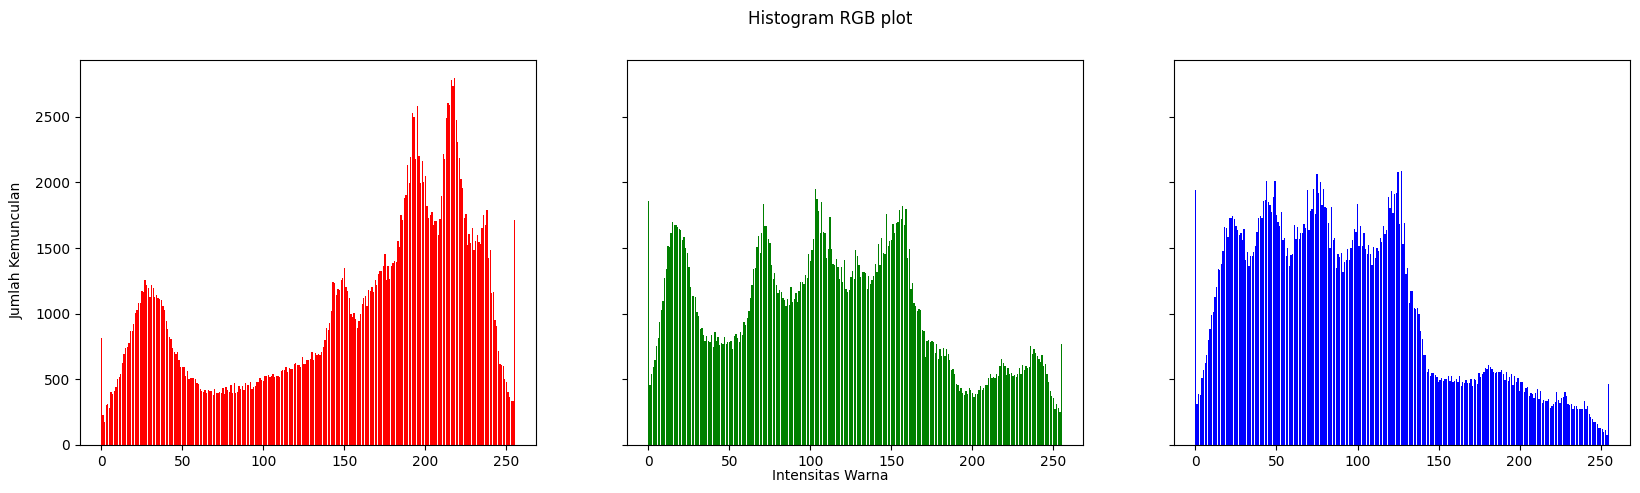

In [9]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

##Pertanyaan E-1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

Jawaban:

In [13]:
import cv2 as cv
import numpy as np

# Load gambar (Sesuaikan path)
img_path = '/content/drive/MyDrive/PCVK/Images/lena.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil satu channel saja untuk pembuktian (misal: Red channel - channel 0)
red_channel = img[:,:,0]

hist_manual = np.zeros(256)
height, width = red_channel.shape
for y in range(height):
    for x in range(width):
        hist_manual[red_channel[y][x]] += 1

hist_np, _ = np.histogram(red_channel.flatten(), bins=256, range=[0,256])

hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

selisih_manual_np = np.max(np.abs(hist_manual - hist_np))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_np_cv = np.max(np.abs(hist_np - hist_cv))

print("Pembuktian Selisih Maksimum:")
print(f"Manual vs NumPy : {selisih_manual_np}")
print(f"Manual vs OpenCV: {selisih_manual_cv}")
print(f"NumPy vs OpenCV : {selisih_np_cv}")

Pembuktian Selisih Maksimum:
Manual vs NumPy : 0.0
Manual vs OpenCV: 0.0
NumPy vs OpenCV : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.

Jawaban:

True


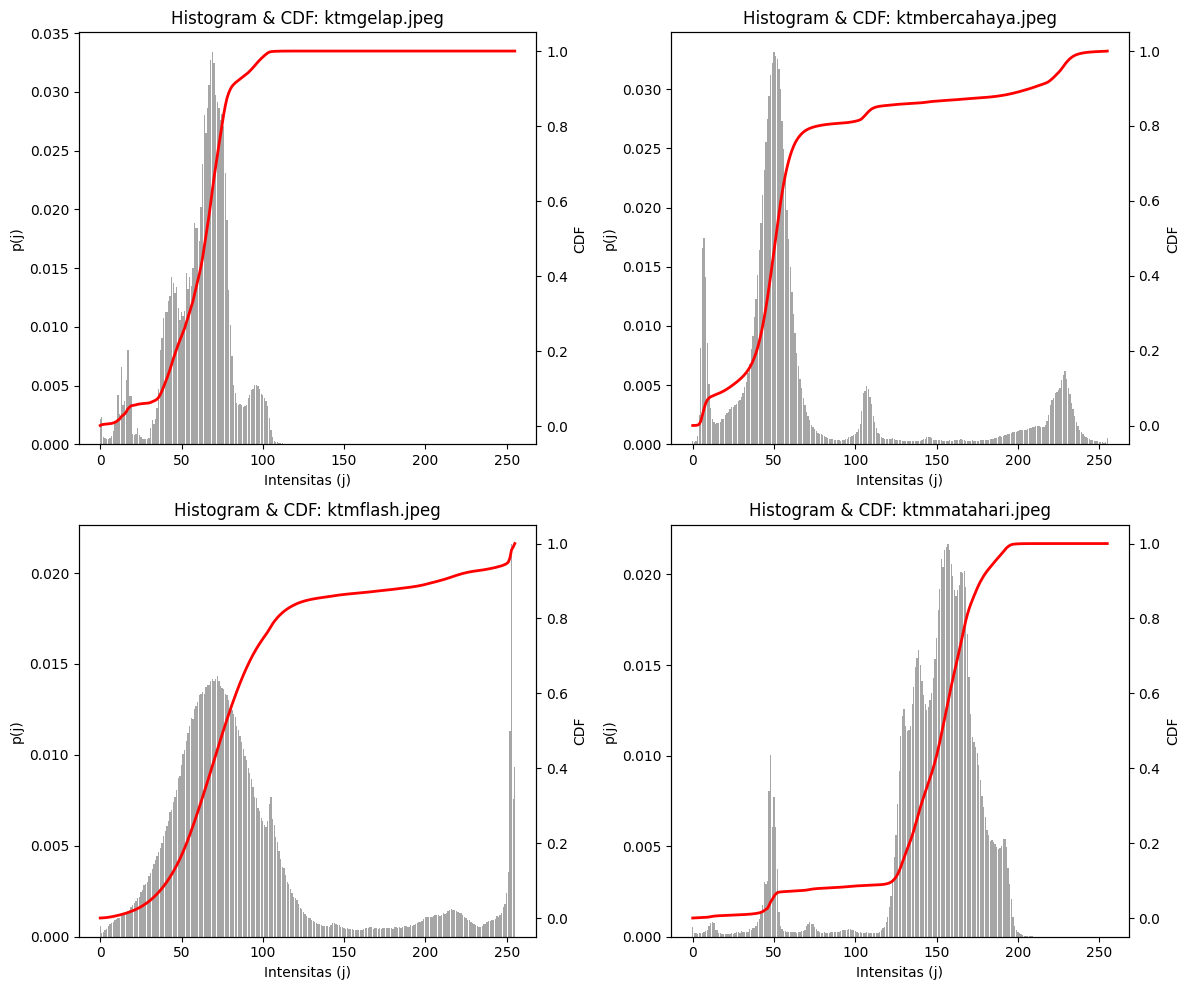

In [17]:
import matplotlib.pyplot as plt

# Daftar nama file citra
citra_list = ['ktmgelap.jpeg', 'ktmbercahaya.jpeg', 'ktmflash.jpeg', 'ktmmatahari.jpeg']
path_folder = '/content/drive/MyDrive/PCVK/Images/KTM/'
print(os.path.exists('/content/drive/MyDrive/PCVK/Images/KTM/'))

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i, nama_file in enumerate(citra_list):
    img_gray = cv.imread(path_folder + nama_file, cv.IMREAD_GRAYSCALE)

    hist_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
    total_pixels = img_gray.shape[0] * img_gray.shape[1]
    p_j = hist_cv / total_pixels

    cdf = p_j.cumsum()

    ax1 = axs[i]
    ax2 = ax1.twinx()

    ax1.bar(np.arange(256), p_j, color='gray', alpha=0.7, label='p(j)')
    ax2.plot(cdf, color='red', linewidth=2, label='CDF')

    ax1.set_title(f'Histogram & CDF: {nama_file}')
    ax1.set_xlabel('Intensitas (j)')
    ax1.set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

Penjelasan Perbedaan Kurva CDF (Gelap vs Terang):

Citra Paling Gelap (Kurang Cahaya/Underexposed): Kurva CDF akan naik sangat tajam di awal (sisi kiri grafik yang mewakili nilai intensitas rendah 0-50) dan kemudian menjadi datar lebih cepat. Hal ini terjadi karena sebagian besar piksel terkonsentrasi pada nilai gelap akibat kurangnya pencahayaan saat akuisisi gambar.

Citra Paling Terang (Kelebihan Cahaya/Overexposed): Kurva CDF akan landai atau datar di bagian awal dan baru naik secara signifikan atau tajam di bagian akhir grafik (sisi kanan mendekati nilai 255). Ini merepresentasikan kondisi pencahayaan yang terlalu kuat sehingga mayoritas piksel memiliki nilai intensitas tinggi.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

Jawaban:

Text(0, 0.5, 'Frekuensi')

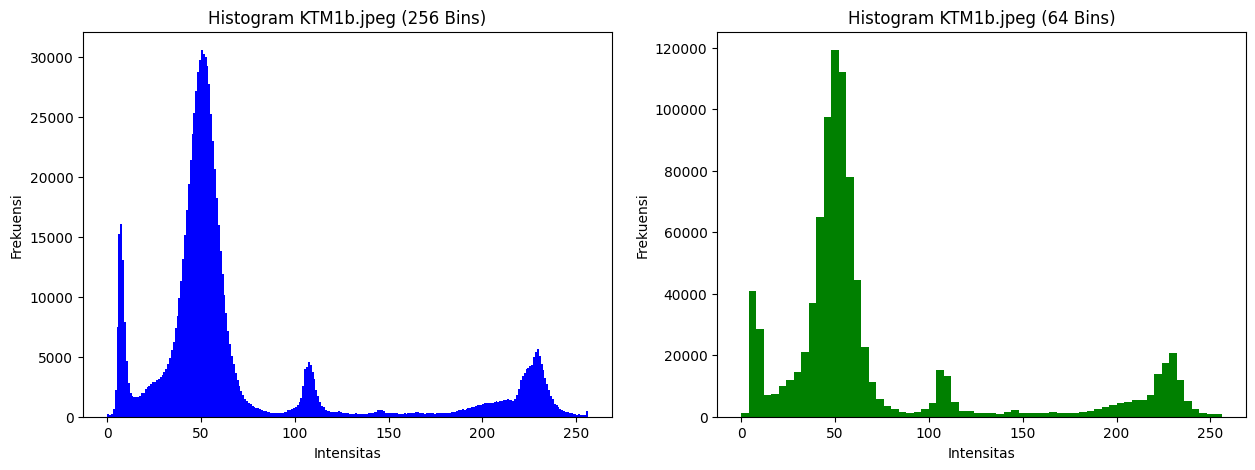

In [18]:
# Asumsi nilai PARAM['bins']
PARAM = {'bins': 64}

img_ktm1b = cv.imread(path_folder + 'ktmbercahaya.jpeg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].hist(img_ktm1b.flatten(), bins=256, range=[0, 256], color='blue')
axs[0].set_title('Histogram KTM1b.jpeg (256 Bins)')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Frekuensi')

axs[1].hist(img_ktm1b.flatten(), bins=PARAM['bins'], range=[0, 256], color='green')
axs[1].set_title(f"Histogram KTM1b.jpeg ({PARAM['bins']} Bins)")
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Frekuensi')

#E-2 PERCOBAAN HISTOGRAM EQUALIZATION

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Langakah 1:

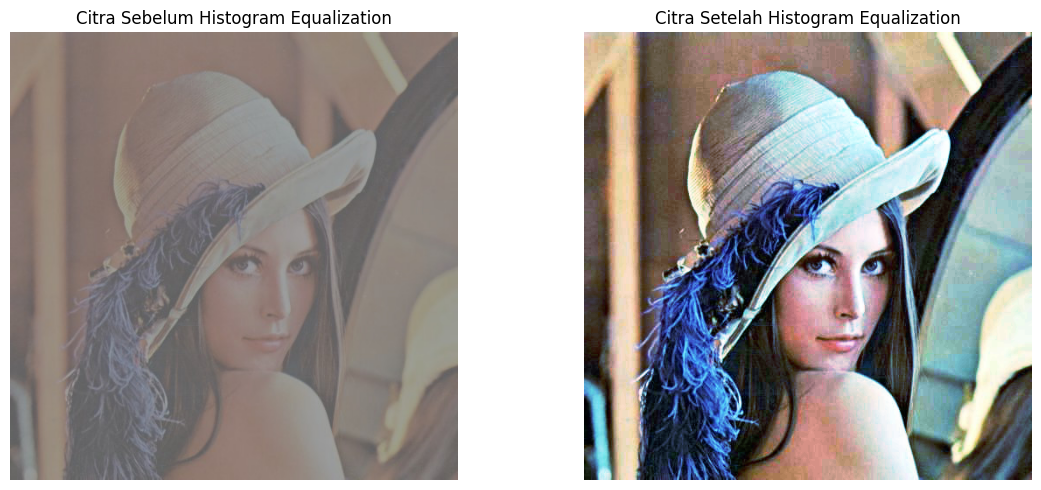

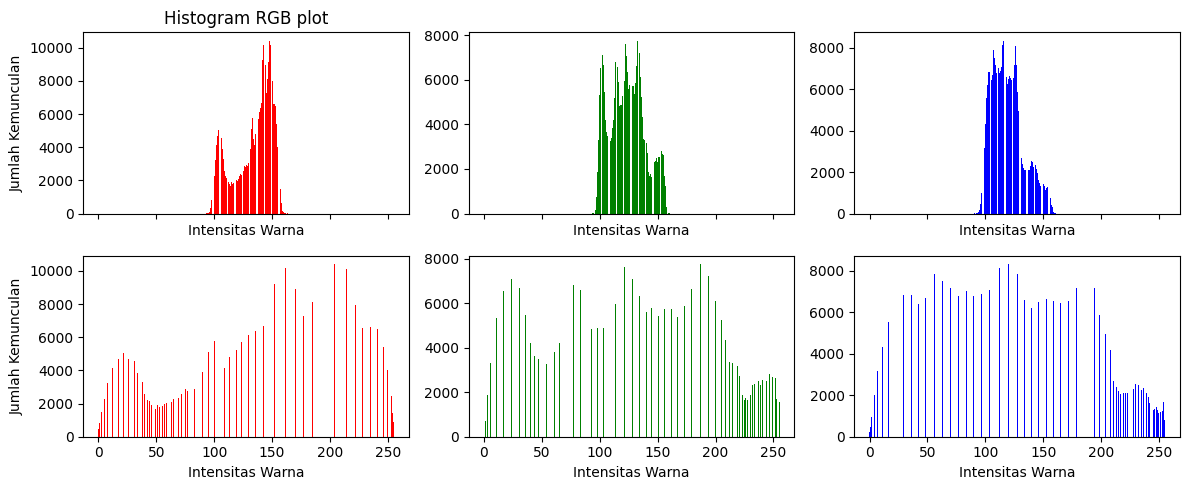

In [24]:
berkas = '/content/drive/MyDrive/PCVK/Images/lena_lc.jpg'

img = cv.imread(berkas)

b, g, r = cv.split(img)

def histogram_equalization(channel):
    hist = np.zeros(256, dtype=np.int64)

    for y in range(channel.shape[0]):
        for x in range(channel.shape[1]):
            hist[channel[y, x]] += 1

    cdf = np.cumsum(hist)
    cdf_norm = cdf / channel.size
    transform = np.round(255 * cdf_norm).astype(np.uint8)

    hasil = transform[channel]

    return hist, hasil

hist_b, b_eq = histogram_equalization(b)
hist_g, g_eq = histogram_equalization(g)
hist_r, r_eq = histogram_equalization(r)

img_equal = cv.merge([b_eq, g_eq, r_eq])

hist_b_eq = np.bincount(b_eq.ravel(), minlength=256)
hist_g_eq = np.bincount(g_eq.ravel(), minlength=256)
hist_r_eq = np.bincount(r_eq.ravel(), minlength=256)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_equal_rgb = cv.cvtColor(img_equal, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Sebelum Histogram Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equal_rgb)
plt.title('Citra Setelah Histogram Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(12, 5), sharex=True)

axs[0, 0].bar(np.arange(256), hist_r, color='red')
axs[0, 1].bar(np.arange(256), hist_g, color='green')
axs[0, 2].bar(np.arange(256), hist_b, color='blue')

axs[1, 0].bar(np.arange(256), hist_r_eq, color='red')
axs[1, 1].bar(np.arange(256), hist_g_eq, color='green')
axs[1, 2].bar(np.arange(256), hist_b_eq, color='blue')

axs[0, 0].set_title('Histogram RGB plot')
axs[0, 0].set_ylabel('Jumlah Kemunculan')
axs[1, 0].set_ylabel('Jumlah Kemunculan')

for ax in axs.flat:
    ax.set_xlabel('Intensitas Warna')

plt.tight_layout()
plt.show()

Langkah 2:

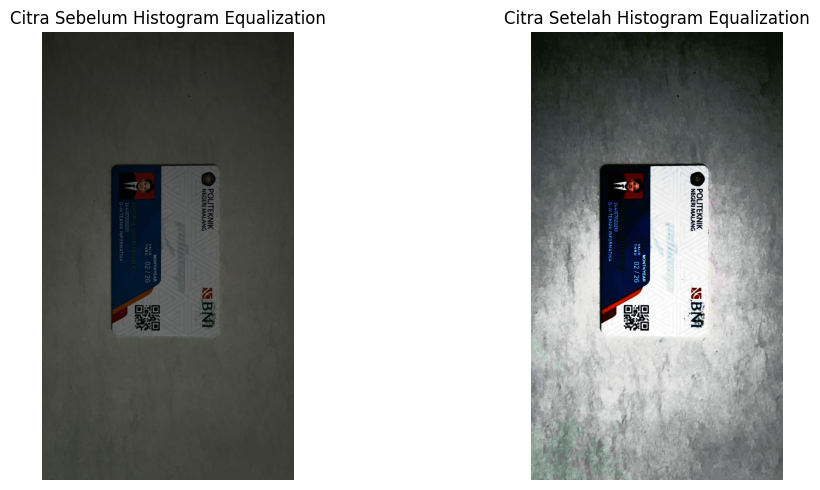

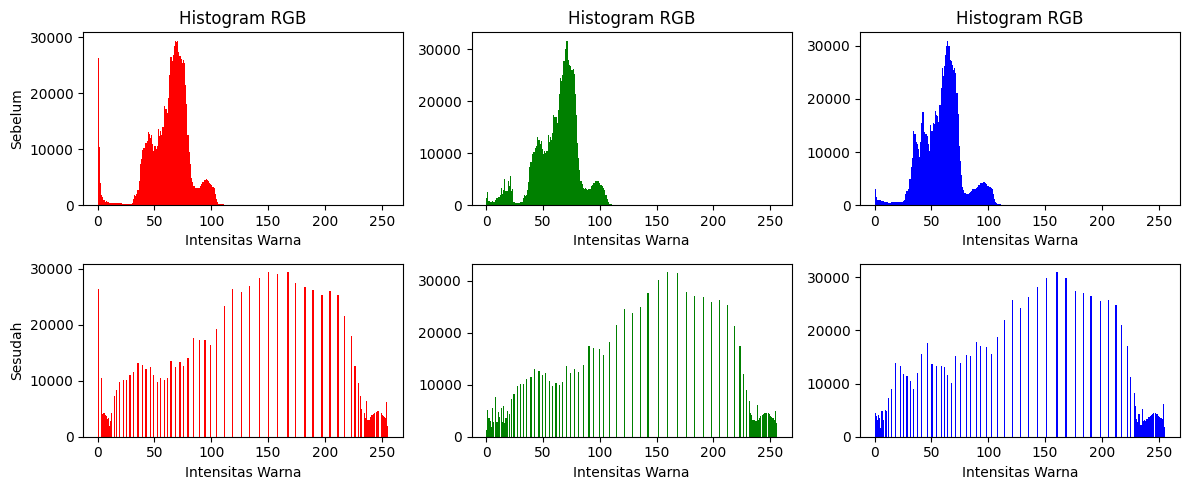

In [26]:
berkas = '/content/drive/MyDrive/PCVK/Images/KTM/ktmgelap.jpeg'

img = cv.imread(berkas)

b, g, r = cv.split(img)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_equalized = cv.merge([b_equalized, g_equalized, r_equalized])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Sebelum Histogram Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_equalized, cv.COLOR_BGR2RGB))
plt.title('Citra Setelah Histogram Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(12, 5))

axs[0, 0].hist(r.ravel(), bins=256, range=(0, 256), color='red')
axs[0, 1].hist(g.ravel(), bins=256, range=(0, 256), color='green')
axs[0, 2].hist(b.ravel(), bins=256, range=(0, 256), color='blue')

axs[1, 0].hist(r_equalized.ravel(), bins=256, range=(0, 256), color='red')
axs[1, 1].hist(g_equalized.ravel(), bins=256, range=(0, 256), color='green')
axs[1, 2].hist(b_equalized.ravel(), bins=256, range=(0, 256), color='blue')

axs[0, 0].set_title('Histogram RGB')
axs[0, 1].set_title('Histogram RGB')
axs[0, 2].set_title('Histogram RGB')

axs[0, 0].set_ylabel('Sebelum')
axs[1, 0].set_ylabel('Sesudah')

for ax in axs.flat:
    ax.set_xlabel('Intensitas Warna')

plt.tight_layout()
plt.show()

Langkah 3:

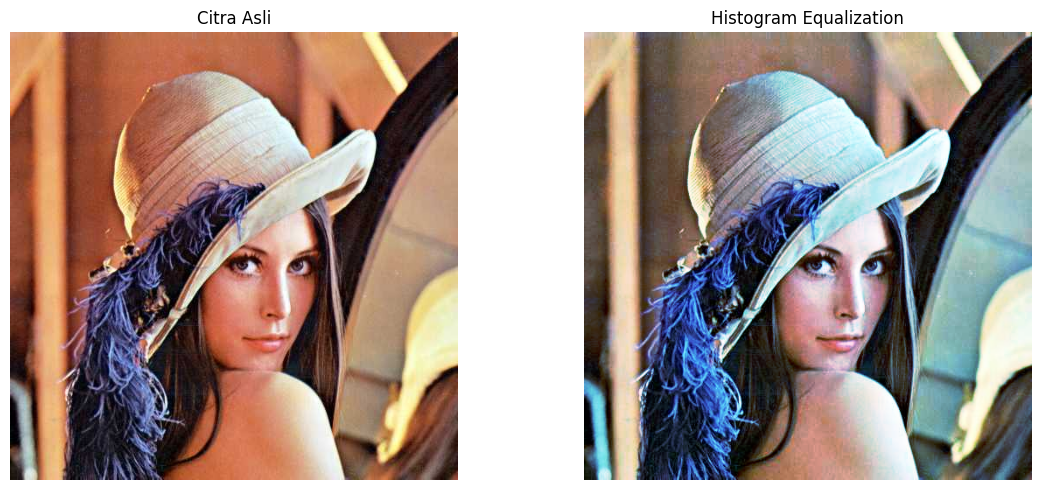

In [36]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PCVK/Images/lena.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title('Histogram Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

Langkah 4:

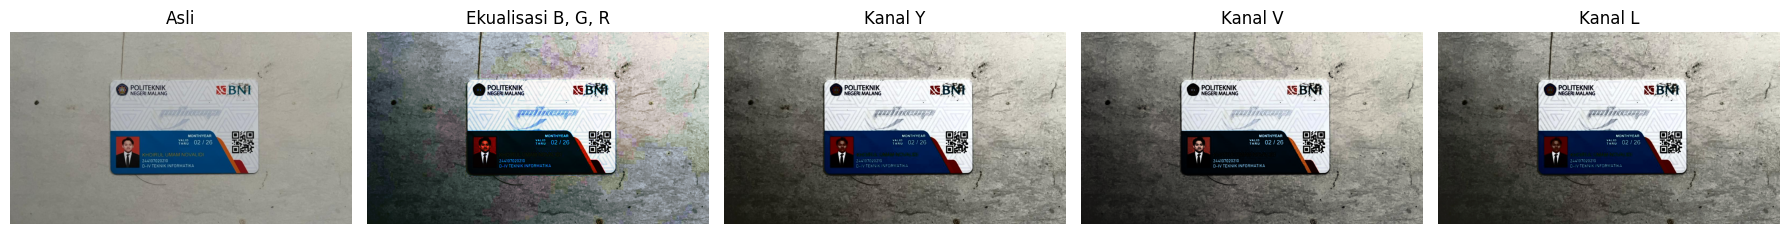

In [40]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PCVK/Images/KTM/ktmmatahari.jpeg'

bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([cv.equalizeHist(y), cr, cb]),
    cv.COLOR_YCrCb2BGR
)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)

he_v = cv.cvtColor(
    cv.merge([h, sat, cv.equalizeHist(v)]),
    cv.COLOR_HSV2BGR
)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)

he_l = cv.cvtColor(
    cv.merge([cv.equalizeHist(l), a, b]),
    cv.COLOR_LAB2BGR
)

citra = [
    bgr,
    he_rgb,
    he_y,
    he_v,
    he_l
]

judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t)
    plt.axis('off')

plt.tight_layout()
plt.show()

Perbandingan

In [41]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))

for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (
        t,
        geser_hue(bgr, c) * 2,
        cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    ))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            146.5
Ekualisasi B, G, R                80.90            127.8
Kanal Y                            1.20            129.9
Kanal V                            2.17            126.0
Kanal L                            7.03            124.6


### Tabel Hasil Perbandingan Histogram Equalization

| Cara equalisisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---:|---:|---|
| Citra asli | - | 146.5 | Citra asli sebagai pembanding |
| Equalisasi kanal B, G, R | 80.90 | 127.8 | Warna berubah cukup signifikan dan kontras meningkat |
| Kanal Y (YCrCb) | 1.20 | 129.9 | Kecerahan meningkat dan warna relatif tetap |
| Kanal V (HSV) | 2.17 | 126.0 | Kecerahan meningkat, warna relatif tetap |
| Kanal L (LAB) | 7.03 | 124.6 | Kecerahan berubah dan warna sedikit bergeser |

Jawaban Pertanyaan:

1. Cara mana yang menghasilkan pergeseran Hue paling besar?
  
  Equalisasi kanal B, G, R menghasilkan pergeseran Hue paling besar, yaitu 80,90°. Nilai ini jauh lebih besar dibandingkan Kanal Y sebesar 1,20°, Kanal V sebesar 2,17°, dan Kanal L sebesar 7,03°.

2. Mengapa equaliasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?

  Karena pada proses konversi ruang warna dan pengembalian citra ke BGR terjadi pembulatan dan pemotongan nilai (clipping). Akibatnya, meskipun informasi warna tidak diequalisasi secara langsung, nilai warna dapat mengalami sedikit perubahan.

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM?

  Berdasarkan angka yang kamu dapat, Kanal Y (YCrCb) memiliki pergeseran Hue paling kecil, yaitu 1,20°, dibandingkan V 2,17° dan L 7,03°. Jadi, untuk foto kamu, Kanal Y dapat dijadikan pilihan berdasarkan ukuran perubahan warna yang paling kecil.

Alasannya:
- Pergeseran Hue paling kecil: 1,20°
- Kecerahan setelah equalization: 129,9
- Warna relatif paling terjaga berdasarkan metrik Hue.

4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.

Cara                       Geser Hue (der)    Rerata terang
Equalisasi Y                          0.92            128.2
CLAHE Kanal Y                         0.18            104.7


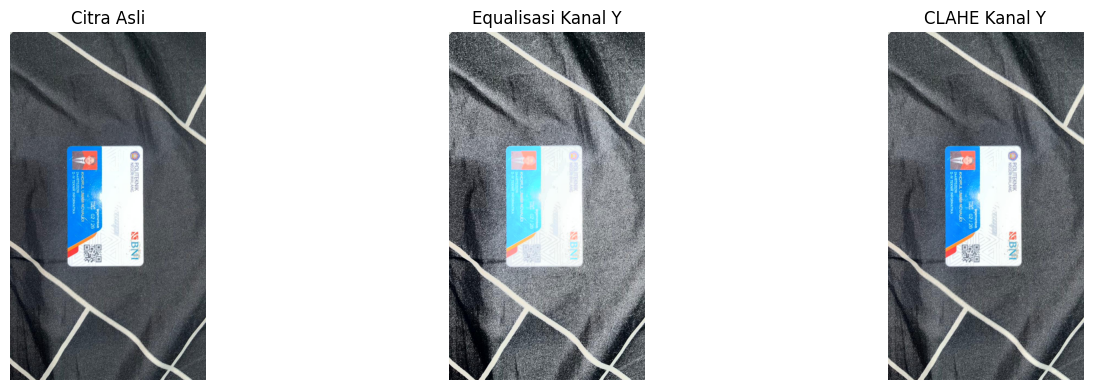

In [43]:
berkas = '/content/drive/MyDrive/PCVK/Images/KTM/ktmflash.jpeg'

bgr = cv.imread(berkas)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([cv.equalizeHist(y), cr, cb]),
    cv.COLOR_YCrCb2BGR
)

clahe = cv.createCLAHE(
    clipLimit=1.0,
    tileGridSize=(4, 4)
)

y_clahe = clahe.apply(y)

clahe_y = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean() * 2

print('%-25s %16s %16s' % ('Cara', 'Geser Hue (der)', 'Rerata terang'))

print('%-25s %16.2f %16.1f' % (
    'Equalisasi Y',
    geser_hue(bgr, he_y),
    cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()
))

print('%-25s %16.2f %16.1f' % (
    'CLAHE Kanal Y',
    geser_hue(bgr, clahe_y),
    cv.cvtColor(clahe_y, cv.COLOR_BGR2GRAY).mean()
))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title('Equalisasi Kanal Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title('CLAHE Kanal Y')
plt.axis('off')

plt.tight_layout()
plt.show()

##Pertanyaan E-2

1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

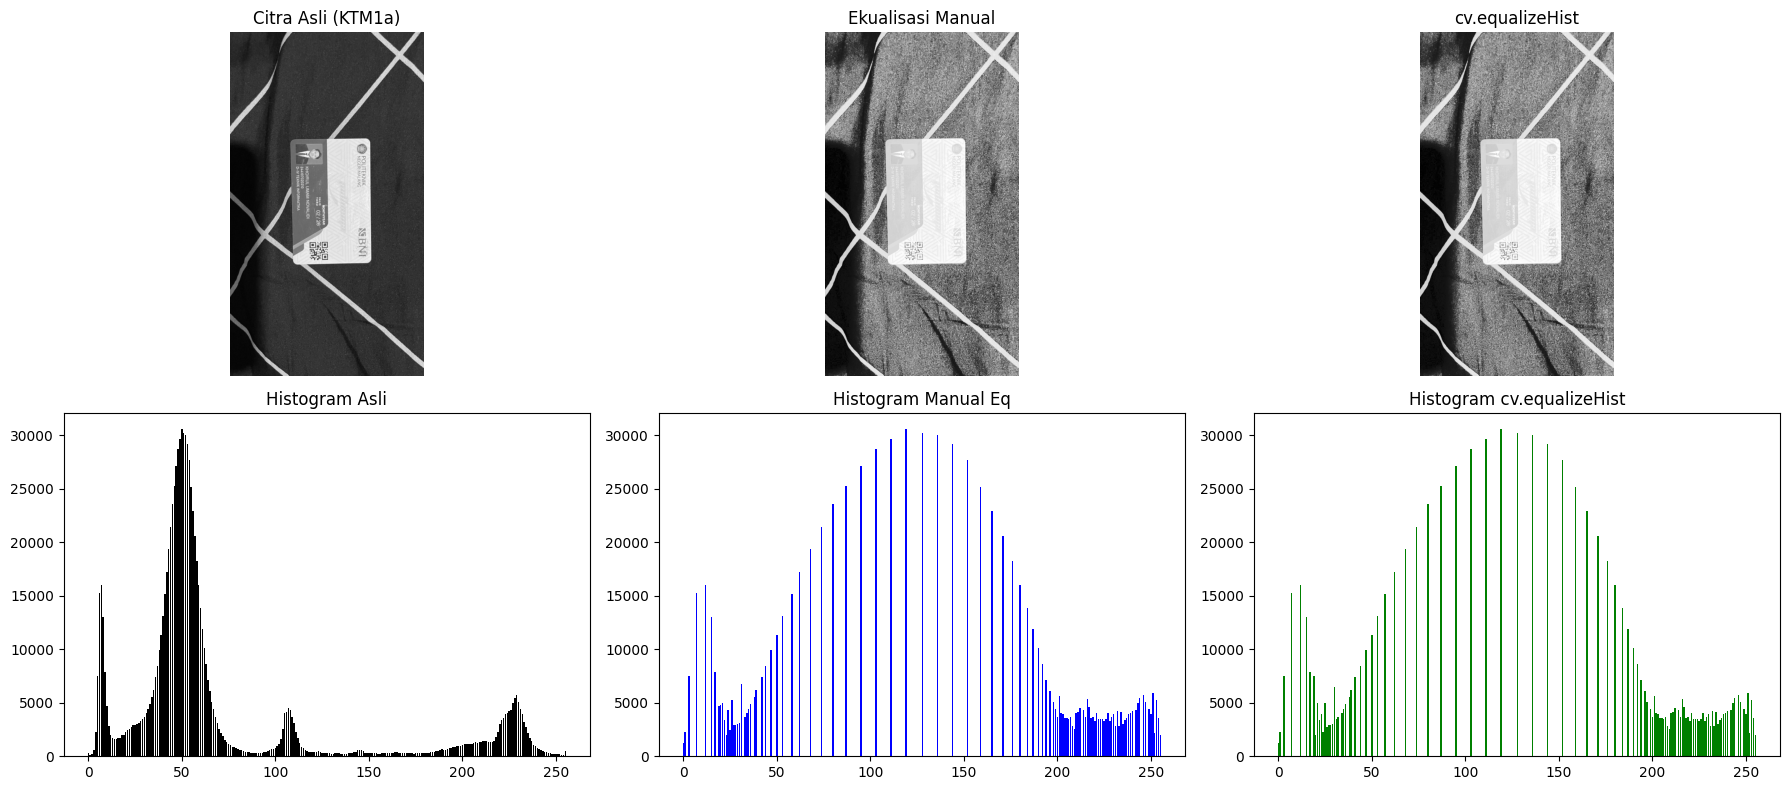

In [44]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load citra grayscale
path_ktm = '/content/drive/MyDrive/PCVK/Images/KTM/ktmbercahaya.jpeg'
img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print("Gambar tidak ditemukan! Cek kembali path citra.")

# 1a. Ekualisasi Manual (Grayscale)
total_pixels = img_gray.shape[0] * img_gray.shape[1]
hist_asli, _ = np.histogram(img_gray.flatten(), bins=256, range=[0,256])
pdf = hist_asli / total_pixels
cdf = np.cumsum(pdf)
transform_map = np.round(cdf * 255).astype('uint8')
img_manual_eq = transform_map[img_gray]

# 1a. Ekualisasi dengan cv.equalizeHist
img_cv_eq = cv.equalizeHist(img_gray)

# Menghitung histogram hasil
hist_manual, _ = np.histogram(img_manual_eq.flatten(), bins=256, range=[0,256])
hist_cv, _ = np.histogram(img_cv_eq.flatten(), bins=256, range=[0,256])

# 1b. Tampilkan citra dan histogram dalam satu layout
fig, axs = plt.subplots(2, 3, figsize=(18, 8))

# Baris 1: Gambar
axs[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title('Citra Asli (KTM1a)')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_manual_eq, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Ekualisasi Manual')
axs[0, 1].axis('off')

axs[0, 2].imshow(img_cv_eq, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title('cv.equalizeHist')
axs[0, 2].axis('off')

# Baris 2: Histogram
axs[1, 0].bar(np.arange(256), hist_asli, color='black')
axs[1, 0].set_title('Histogram Asli')

axs[1, 1].bar(np.arange(256), hist_manual, color='blue')
axs[1, 1].set_title('Histogram Manual Eq')

axs[1, 2].bar(np.arange(256), hist_cv, color='green')
axs[1, 2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

In [45]:
# 1c. Hitung PSNR antara citra asli dan hasil ekualisasi
psnr_manual = cv.PSNR(img_gray, img_manual_eq)
psnr_cv = cv.PSNR(img_gray, img_cv_eq)

print("=== PERHITUNGAN PSNR ===")
print(f"PSNR Asli vs Manual Eq    : {psnr_manual:.2f} dB")
print(f"PSNR Asli vs cv.equalizeHist: {psnr_cv:.2f} dB")

=== PERHITUNGAN PSNR ===
PSNR Asli vs Manual Eq    : 10.88 dB
PSNR Asli vs cv.equalizeHist: 10.88 dB


Jawaban Analisis 1c (PSNR):

- Mengapa PSNR turun padahal citra lebih jelas? PSNR (Peak Signal-to-Noise Ratio) pada dasarnya menghitung selisih atau error matematis piksel-per-piksel (MSE) antara dua gambar. Ekualisasi histogram secara sengaja mengubah nilai piksel secara drastis untuk meregangkan kontras. Karena nilai piksel gambar hasil ekualisasi sangat berbeda secara matematis dengan gambar asli (MSE menjadi besar), nilai PSNR otomatis akan anjlok.

- Kesimpulan: PSNR tidak layak digunakan untuk menilai keterbacaan (readability) atau peningkatan kualitas visual pada proses image enhancement (seperti ekualisasi kontras). PSNR hanya cocok untuk mengukur fidelity (kesetiaan/kemiripan) misalnya pada proses kompresi citra, di mana tujuannya adalah meminimalkan perubahan dari citra asli.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.

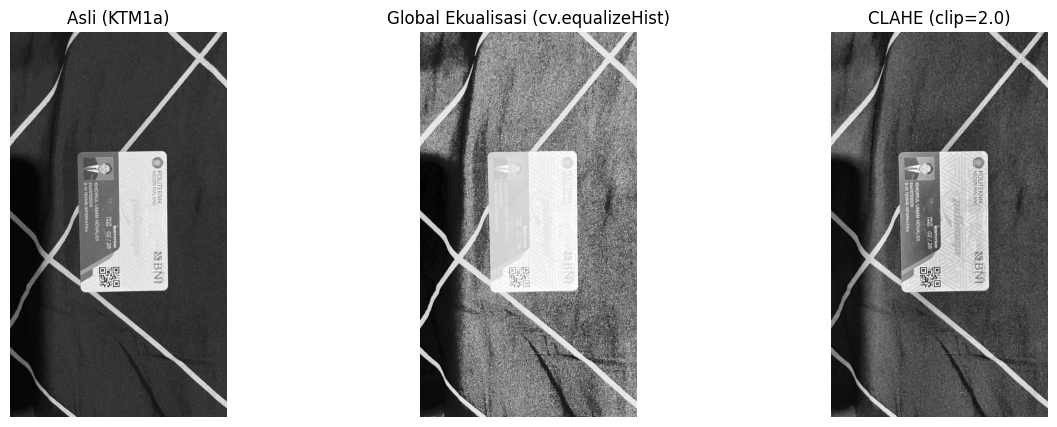

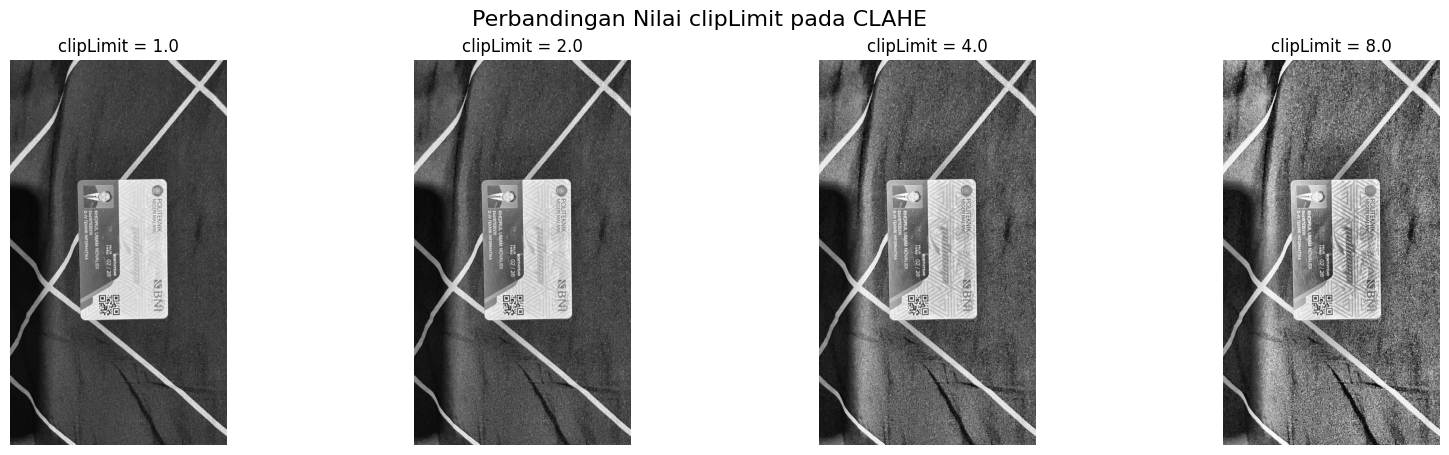

In [46]:
# parameter dasar
PARAM = {'clip': 2.0, 'tile': 8}

# 2a. Terapkan CLAHE berdasarkan parameter dasar
clahe_base = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe_base = clahe_base.apply(img_gray)

# 2b. Uji coba 3 nilai clipLimit lain di sekitar nilai parameter (misal: 1.0, 4.0, 8.0)
clip_limits = [1.0, 2.0, 4.0, 8.0] # 2.0 adalah nilai asli (PARAM['clip'])
img_clahe_results = []

for clip in clip_limits:
    clahe_temp = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    img_clahe_results.append(clahe_temp.apply(img_gray))

# Menampilkan perbandingan Global Eq vs CLAHE Dasar (2a)
fig_comp, axs_comp = plt.subplots(1, 3, figsize=(15, 5))
axs_comp[0].imshow(img_gray, cmap='gray')
axs_comp[0].set_title('Asli (KTM1a)')
axs_comp[1].imshow(img_cv_eq, cmap='gray')
axs_comp[1].set_title('Global Ekualisasi (cv.equalizeHist)')
axs_comp[2].imshow(img_clahe_base, cmap='gray')
axs_comp[2].set_title(f"CLAHE (clip={PARAM['clip']})")
for ax in axs_comp: ax.axis('off')
plt.show()

# Menampilkan perbandingan berbagai nilai clipLimit (2b)
fig_clip, axs_clip = plt.subplots(1, 4, figsize=(20, 5))
fig_clip.suptitle('Perbandingan Nilai clipLimit pada CLAHE', fontsize=16)

for i in range(4):
    axs_clip[i].imshow(img_clahe_results[i], cmap='gray', vmin=0, vmax=255)
    axs_clip[i].set_title(f'clipLimit = {clip_limits[i]}')
    axs_clip[i].axis('off')
plt.show()

Jawaban Analisis 2a & 2b:

  a. Perbandingan dengan Ekualisasi Global:
  
  NIM dan nama pada kartu (teks) akan lebih terbaca pada hasil CLAHE. Ekualisasi global menarik kontras citra secara keseluruhan, sehingga area yang awalnya sudah agak terang (seperti wajah atau blok teks putih) bisa menjadi terlalu putih rata (washed out), menghilangkan detail batas huruf. CLAHE membagi gambar ke dalam grid berukuran 8x8 piksel dan melakukan ekualisasi di area lokal tersebut, sehingga kontras teks terhadap background terdekatnya meningkat tajam tanpa terpengaruh oleh pencahayaan bagian lain dari kartu.

  b. Analisis Nilai clipLimit Terbaik dan Kemunculan Noise:
  
  Nilai Terbaik: Umumnya clipLimit = 2.0 (atau 3.0) adalah nilai terbaik. Nilai ini memberikan keseimbangan yang pas antara peningkatan kontras teks sehingga huruf terlihat jelas, tanpa membuat latar belakang menjadi sangat berbintik.
  Munculnya Noise: Ketika nilai clipLimit dinaikkan menjadi 4.0 dan 8.0, noise (titik-titik kasar/bintik-bintik artifisial) mulai sangat menonjol. Bagian citra yang noise-nya paling terlihat adalah pada area yang homogen/warnanya rata, seperti background polos di luar kartu, area jas/baju yang rata, dan ruang kosong pada latar belakang kartu KTM itu sendiri. Hal ini terjadi karena CLAHE berupaya keras meningkatkan batas kontras di area yang sebenarnya tidak memiliki detail, sehingga yang ditingkatkan adalah derau/noise bawaan sensor kamera.

##E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

Fungsi Dithering Floyd-Steinberg:

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L):
    # Mengubah tipe data ke float32 berdasarkan flowchart
    img = np.float32(gray)
    step = 255 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Distribusi error Floyd-Steinberg
            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    # Membatasi nilai 0-255 dan mengembalikan ke uint8
    img = np.clip(img, 0, 255)
    return np.uint8(img)

# Asumsi level L = 2
PARAM = {'L': 2}

Jawab Nomor 1:

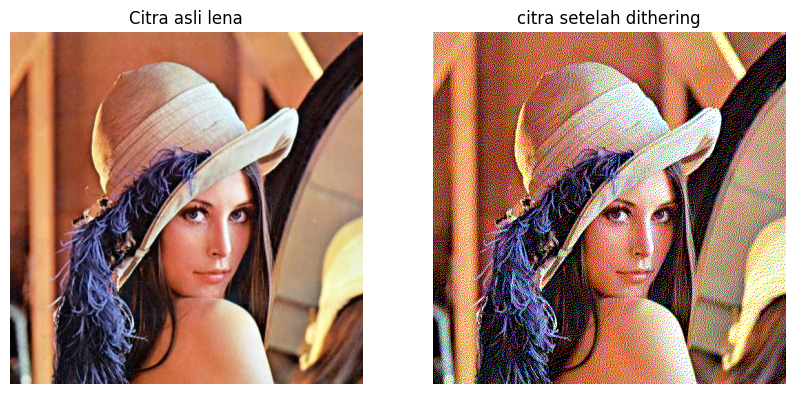

In [48]:
img_lena_bgr = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_lena_rgb = cv2.cvtColor(img_lena_bgr, cv2.COLOR_BGR2RGB)

# Memisahkan channel warna Red, Green, Blue
r, g, b = cv2.split(img_lena_rgb)

# Proses dithering pada masing-masing channel warna
r_dither = floyd_steinberg(r, PARAM['L'])
g_dither = floyd_steinberg(g, PARAM['L'])
b_dither = floyd_steinberg(b, PARAM['L'])

# Menggabungkan kembali channel warna yang sudah di-dither
dither_lena_rgb = cv2.merge((r_dither, g_dither, b_dither))

# Menampilkan hasil agar sesuai dengan contoh di modul
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_lena_rgb)
axes[0].set_title('Citra asli lena')
axes[0].axis('off')

axes[1].imshow(dither_lena_rgb)
axes[1].set_title('citra setelah dithering')
axes[1].axis('off')

plt.show()

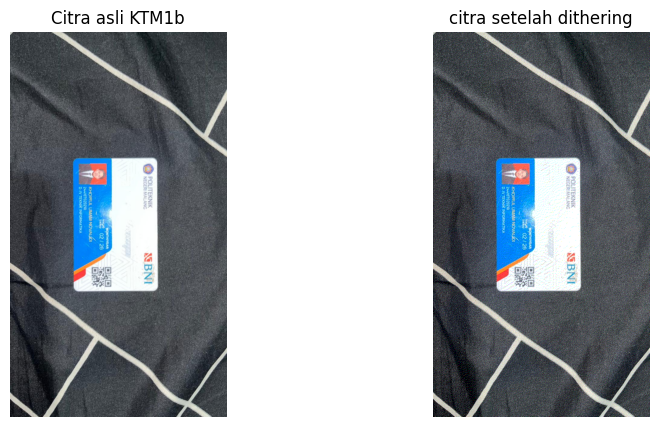

In [49]:
img_ktm1b_bgr = cv2.imread('/content/drive/MyDrive/PCVK/Images/KTM/ktmflash.jpeg')
img_ktm1b_rgb = cv2.cvtColor(img_ktm1b_bgr, cv2.COLOR_BGR2RGB)

# Memisahkan channel warna
r_ktm, g_ktm, b_ktm = cv2.split(img_ktm1b_rgb)

# Proses dithering pada masing-masing channel
r_ktm_dither = floyd_steinberg(r_ktm, PARAM['L'])
g_ktm_dither = floyd_steinberg(g_ktm, PARAM['L'])
b_ktm_dither = floyd_steinberg(b_ktm, PARAM['L'])

# Menggabungkan kembali channel
dither_ktm1b_rgb = cv2.merge((r_ktm_dither, g_ktm_dither, b_ktm_dither))

# Menampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_ktm1b_rgb)
axes[0].set_title('Citra asli KTM1b')
axes[0].axis('off')

axes[1].imshow(dither_ktm1b_rgb)
axes[1].set_title('citra setelah dithering')
axes[1].axis('off')

plt.show()

Jawab Nomor 2:

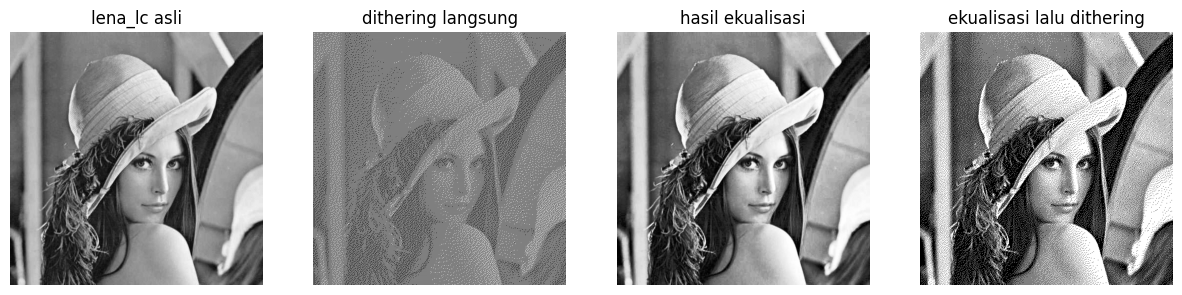

In [50]:
img_lena_lc = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg', cv2.IMREAD_GRAYSCALE)

# 1. Dithering langsung tanpa ekualisasi
dither_langsung = floyd_steinberg(img_lena_lc, PARAM['L'])

# 2. Histogram Equalization
eq_lena = cv2.equalizeHist(img_lena_lc)

# 3. Dithering setelah ekualisasi
dither_eq = floyd_steinberg(eq_lena, PARAM['L'])

# Menampilkan 4 perbandingan
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ['lena_lc asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']
images = [img_lena_lc, dither_langsung, eq_lena, dither_eq]

for ax, title, image in zip(axes, titles, images):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

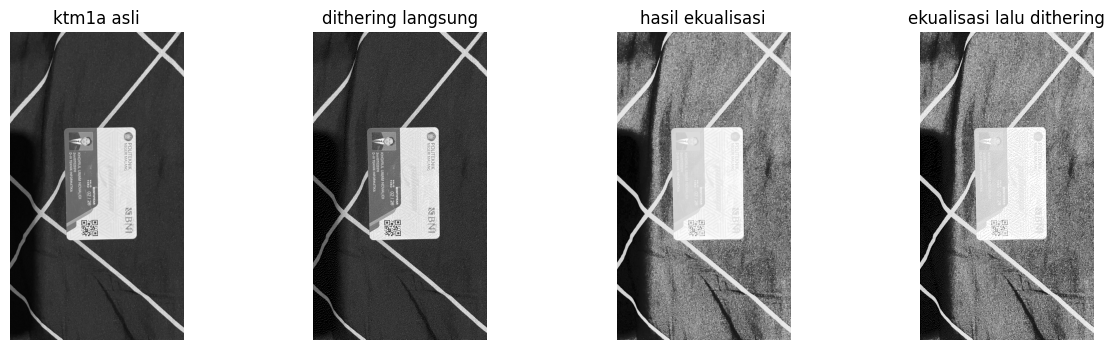

In [51]:
img_ktm1a = cv2.imread('/content/drive/MyDrive/PCVK/Images/KTM/ktmbercahaya.jpeg', cv2.IMREAD_GRAYSCALE)

# 1. Dithering langsung tanpa ekualisasi
dither_langsung_ktm = floyd_steinberg(img_ktm1a, PARAM['L'])

# 2. Histogram Equalization
eq_ktm = cv2.equalizeHist(img_ktm1a)

# 3. Dithering setelah ekualisasi
dither_eq_ktm = floyd_steinberg(eq_ktm, PARAM['L'])

# Menampilkan 4 perbandingan
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ['ktm1a asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']
images = [img_ktm1a, dither_langsung_ktm, eq_ktm, dither_eq_ktm]

for ax, title, image in zip(axes, titles, images):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

Penjelasan:

- Jika dilakukan Dithering Langsung: Citra asli (KTM1a.jpg atau lena_lc.jpg) memiliki kontras yang sangat rendah di mana mayoritas intensitas warna berkumpul di area gelap. Saat proses dithering dilakukan dengan Level terbatas (misal L=2), sebagian besar nilai piksel yang rendah tersebut akan langsung dibulatkan ke nilai terkecil (hitam polos). Akibatnya, detail struktur huruf, angka NIM, dan batas objek akan tertelan oleh piksel gelap karena minimnya ruang penyebaran error.

- Jika dilakukan Ekualisasi Dahulu: Proses Histogram Equalization akan meregangkan nilai intensitas piksel citra sehingga kontrasnya menyebar secara penuh dari terang ke gelap. Batas antara teks terang dan latar belakang menjadi jauh lebih tajam. Ketika dithering diterapkan pada citra yang sudah diekualisasi ini, algoritma penyebaran error (Floyd-Steinberg) dapat bekerja optimal dalam merepresentasikan lekukan huruf menggunakan titik-titik (dots), sehingga teks pada KTM tetap dapat dibaca.